# Picker Penalty Sweep: TD-Lambda vs Supervised Learning

**Goal**: Determine if the bias/variance pattern in TD-lambda learning is caused by:
1. TD mechanics (bootstrapping, target networks) → Supervised should fix it
2. Something fundamental about reward magnitude → Both methods show same pattern

**Experiment**: 15 picker penalty values × 2 methods = 30 experiments

Picker values: -2.0, -1.0, -0.7, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0

In [15]:
import sys
import re
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../../")
from log_file_parser import LogParser

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [16]:
# Configuration
OUTPUT_DIR = Path("outputs")
PICKER_VALUES = [-2.0, -1.0, -0.7, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.25, 0.5, 1.0, 1.5, 2.0]
METHODS = ["td_lambda", "supervised"]

## 1. Load and Parse Log Files

In [17]:
def extract_picker_penalty_from_filename(filename: str) -> float:
    """Extract picker penalty value from log filename."""
    # Pattern: picker_penalty_-0.5 or picker_penalty_0.25
    match = re.search(r'picker_penalty_(-?[\d\.]+)', filename)
    if match:
        return float(match.group(1))
    return None

def extract_method_from_filename(filename: str) -> str:
    """Extract learning method from log filename."""
    if 'supervised' in filename.lower():
        return 'supervised'
    elif 'tdl' in filename.lower() or 'td_lambda' in filename.lower():
        return 'td_lambda'
    return 'unknown'

def parse_agent_loss_from_line(line: str) -> list:
    """Parse AgentLoss: [0.1,0.2,0.3,0.4] from a log line."""
    match = re.search(r'AgentLoss:\s*\[([\d\.,]+)\]', line)
    if match:
        return [float(x) for x in match.group(1).split(',')]
    return None

# Find all log files
log_files = list(OUTPUT_DIR.glob("*.txt"))
print(f"Found {len(log_files)} log files")

# Parse each file
all_data = []
final_metrics = []  # Store final step metrics for each experiment

for log_file in log_files:
    picker_val = extract_picker_penalty_from_filename(log_file.name)
    method = extract_method_from_filename(log_file.name)
    
    if picker_val is None or method == 'unknown':
        print(f"Skipping: {log_file.name}")
        continue
    
    # Parse with LogParser
    df = LogParser.parse_file(str(log_file))
    
    if df.empty:
        print(f"Empty or unparseable: {log_file.name}")
        continue
    
    # Add metadata columns
    df['picker_penalty'] = picker_val
    df['method'] = method
    df['filename'] = log_file.name
    
    # Parse AgentLoss separately (not in LogParser)
    agent_losses = {i: [] for i in range(4)}
    with open(log_file, 'r') as f:
        for line in f:
            losses = parse_agent_loss_from_line(line)
            if losses:
                for i, loss in enumerate(losses):
                    agent_losses[i].append(loss)
    
    # Add agent losses to dataframe if available
    for i in range(4):
        col_name = f'agent_loss_{i}'
        if len(agent_losses[i]) == len(df):
            df[col_name] = agent_losses[i]
    
    all_data.append(df)
    
    # Store final metrics
    final_row = df.iloc[-1].to_dict()
    final_row['picker_penalty'] = picker_val
    final_row['method'] = method
    final_metrics.append(final_row)
    
    print(f"Parsed: {log_file.name} | picker={picker_val} | method={method} | steps={len(df)}")

# Combine all data
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    final_df = pd.DataFrame(final_metrics)
    print(f"\nTotal rows: {len(combined_df)}")
    print(f"Experiments: {len(final_df)}")
else:
    print("No data loaded!")

Found 30 log files
Parsed: picker_sweep_supervised_supervised_MLP_9x9_4ag_picker_penalty_-0.4_g0.99_mlp64x2_pid771914.txt | picker=-0.4 | method=supervised | steps=5
Parsed: picker_sweep_supervised_supervised_MLP_9x9_4ag_picker_penalty_2.0_g0.99_mlp64x2_pid1574301.txt | picker=2.0 | method=supervised | steps=6
Parsed: picker_sweep_td_lambda_tdl0.95_MLP_9x9_4ag_picker_penalty_-0.7_g0.99_mlp64x2_pid2342002.txt | picker=-0.7 | method=td_lambda | steps=499
Parsed: picker_sweep_td_lambda_tdl0.95_MLP_9x9_4ag_picker_penalty_-0.4_g0.99_mlp64x2_pid2355720.txt | picker=-0.4 | method=td_lambda | steps=499
Parsed: picker_sweep_supervised_supervised_MLP_9x9_4ag_picker_penalty_-0.7_g0.99_mlp64x2_pid3913835.txt | picker=-0.7 | method=supervised | steps=5
Parsed: picker_sweep_supervised_supervised_MLP_9x9_4ag_picker_penalty_-1.0_g0.99_mlp64x2_pid3194509.txt | picker=-1.0 | method=supervised | steps=5
Parsed: picker_sweep_td_lambda_tdl0.95_MLP_9x9_4ag_picker_penalty_0.0_g0.99_mlp64x2_pid3164577.txt | p

/tmp/ipykernel_2970250/2567635515.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(all_data, ignore_index=True)


In [18]:
# Quick summary of what we have
if 'final_df' in dir() and not final_df.empty:
    summary = final_df.groupby(['method', 'picker_penalty']).size().unstack(fill_value=0)
    print("Experiments per (method, picker_penalty):")
    display(summary)
else:
    print("No final_df available")

Experiments per (method, picker_penalty):


picker_penalty,-2.00,-1.00,-0.70,-0.50,-0.40,-0.30,-0.20,-0.10,0.00,0.10,0.25,0.50,1.00,1.50,2.00
method,,,,,,,,,,,,,,,
supervised,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
td_lambda,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


## 2. Final Metrics Comparison: TD-Lambda vs Supervised

In [19]:
# Prepare data for plotting
td_data = final_df[final_df['method'] == 'td_lambda'].sort_values('picker_penalty')
sup_data = final_df[final_df['method'] == 'supervised'].sort_values('picker_penalty')

print(f"TD-Lambda experiments: {len(td_data)}")
print(f"Supervised experiments: {len(sup_data)}")

TD-Lambda experiments: 15
Supervised experiments: 15


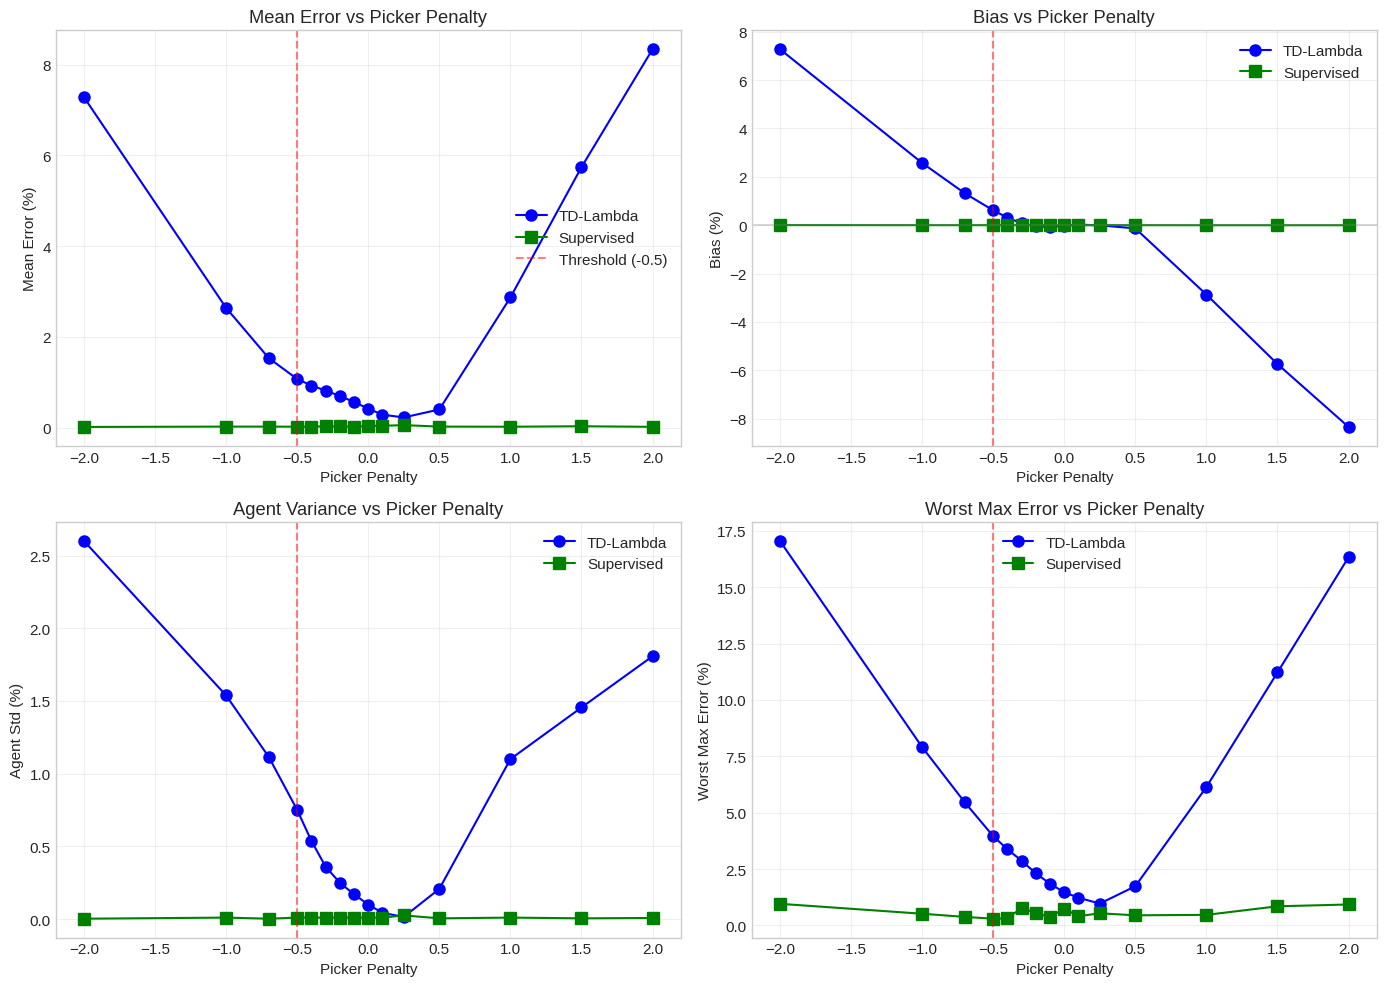

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean Error vs Picker Penalty
ax = axes[0, 0]
if 'avg_mean_error' in td_data.columns:
    ax.plot(td_data['picker_penalty'], td_data['avg_mean_error'], 'o-', label='TD-Lambda', color='blue', markersize=8)
if 'avg_mean_error' in sup_data.columns:
    ax.plot(sup_data['picker_penalty'], sup_data['avg_mean_error'], 's-', label='Supervised', color='green', markersize=8)
ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5, label='Threshold (-0.5)')
ax.set_xlabel('Picker Penalty')
ax.set_ylabel('Mean Error (%)')
ax.set_title('Mean Error vs Picker Penalty')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Bias vs Picker Penalty
ax = axes[0, 1]
if 'avg_bias' in td_data.columns:
    ax.plot(td_data['picker_penalty'], td_data['avg_bias'], 'o-', label='TD-Lambda', color='blue', markersize=8)
if 'avg_bias' in sup_data.columns:
    ax.plot(sup_data['picker_penalty'], sup_data['avg_bias'], 's-', label='Supervised', color='green', markersize=8)
ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Picker Penalty')
ax.set_ylabel('Bias (%)')
ax.set_title('Bias vs Picker Penalty')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Agent Variance (std across agents) vs Picker Penalty
ax = axes[1, 0]
if 'avg_agent_std' in td_data.columns:
    ax.plot(td_data['picker_penalty'], td_data['avg_agent_std'], 'o-', label='TD-Lambda', color='blue', markersize=8)
if 'avg_agent_std' in sup_data.columns:
    ax.plot(sup_data['picker_penalty'], sup_data['avg_agent_std'], 's-', label='Supervised', color='green', markersize=8)
ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Picker Penalty')
ax.set_ylabel('Agent Std (%)')
ax.set_title('Agent Variance vs Picker Penalty')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Max Error vs Picker Penalty
ax = axes[1, 1]
if 'worst_max_error' in td_data.columns:
    ax.plot(td_data['picker_penalty'], td_data['worst_max_error'], 'o-', label='TD-Lambda', color='blue', markersize=8)
if 'worst_max_error' in sup_data.columns:
    ax.plot(sup_data['picker_penalty'], sup_data['worst_max_error'], 's-', label='Supervised', color='green', markersize=8)
ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Picker Penalty')
ax.set_ylabel('Worst Max Error (%)')
ax.set_title('Worst Max Error vs Picker Penalty')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Per-Agent Error Analysis

In [21]:
# Get per-agent columns from any category (e.g., self_picker)
# Categories typically: self_picker, other_picker, zero_actor_miss, zero_self_on_apple

def get_per_agent_mean_errors(df_row, category='self_picker'):
    """Extract per-agent errors for a category."""
    errors = []
    for i in range(4):
        col = f'{category}_A{i}'
        if col in df_row.index:
            errors.append(df_row[col])
    return errors

# Check which categories exist
sample_cols = final_df.columns.tolist()
categories = set()
for col in sample_cols:
    match = re.match(r'([a-zA-Z_]+)_A\d+', col)
    if match:
        categories.add(match.group(1))
        
print(f"Categories with per-agent data: {categories}")

Categories with per-agent data: {'other_picker', 'self_picker', 'zero_actor_miss', 'zero_self_on_apple'}


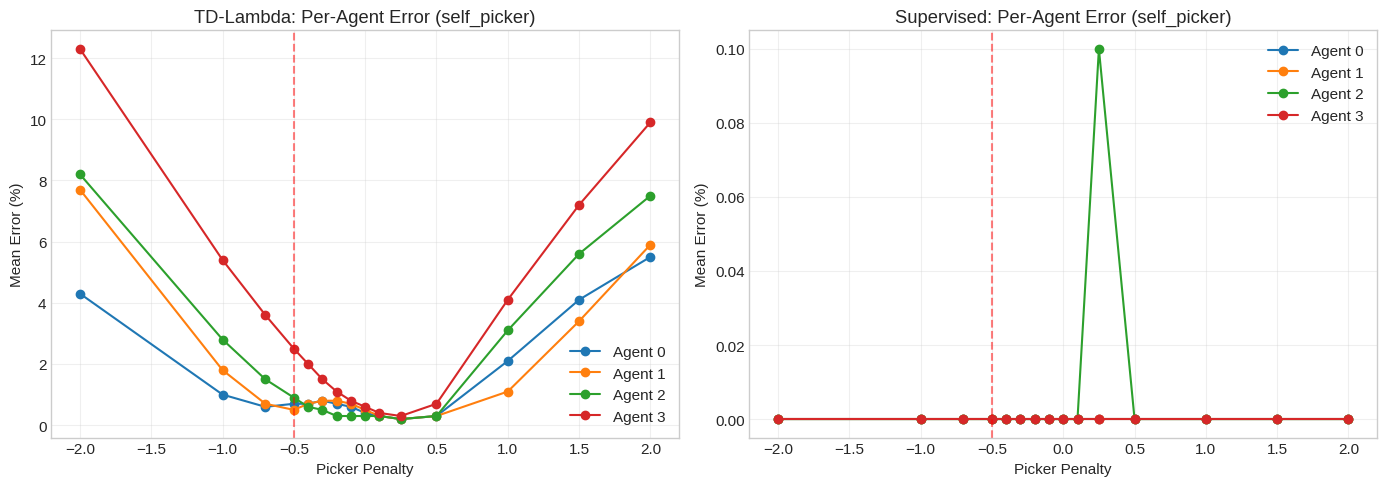

In [22]:
# Plot per-agent errors for a specific category
category = 'self_picker'  # Change as needed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, data) in zip(axes, [('TD-Lambda', td_data), ('Supervised', sup_data)]):
    for i in range(4):
        col = f'{category}_A{i}'
        if col in data.columns:
            ax.plot(data['picker_penalty'], data[col], 'o-', label=f'Agent {i}', markersize=6)
    
    ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Picker Penalty')
    ax.set_ylabel('Mean Error (%)')
    ax.set_title(f'{method}: Per-Agent Error ({category})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Per-Agent Loss Analysis

Agent loss columns: ['agent_loss_0', 'agent_loss_1', 'agent_loss_2', 'agent_loss_3']


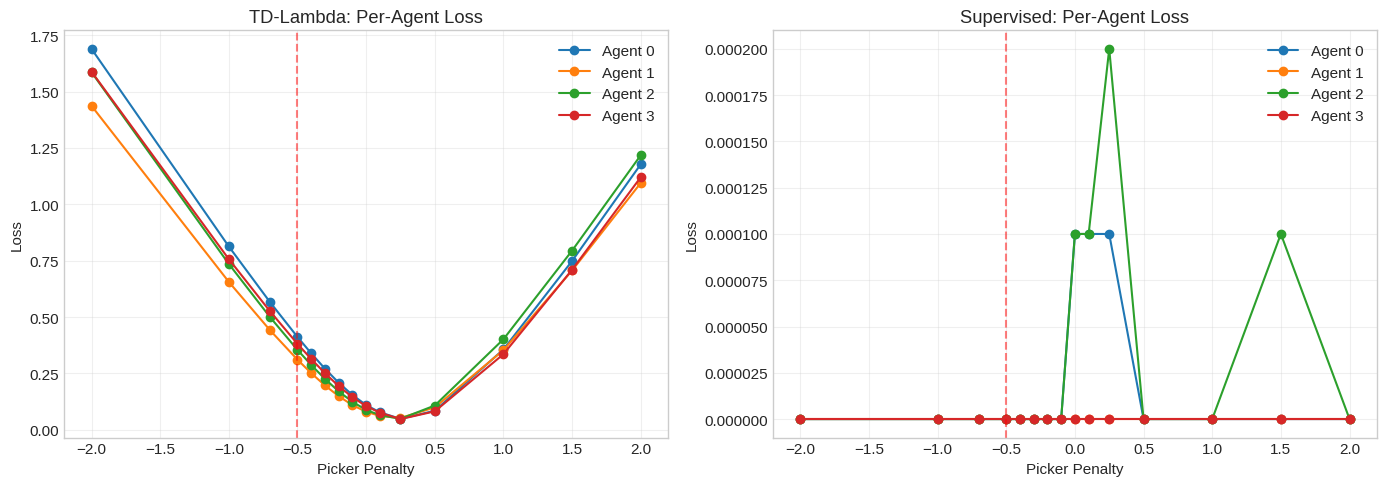

In [23]:
# Check if agent loss data is available
loss_cols = [c for c in final_df.columns if 'agent_loss' in c]
print(f"Agent loss columns: {loss_cols}")

if loss_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, (method, data) in zip(axes, [('TD-Lambda', td_data), ('Supervised', sup_data)]):
        for i in range(4):
            col = f'agent_loss_{i}'
            if col in data.columns:
                ax.plot(data['picker_penalty'], data[col], 'o-', label=f'Agent {i}', markersize=6)
        
        ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Picker Penalty')
        ax.set_ylabel('Loss')
        ax.set_title(f'{method}: Per-Agent Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No agent loss data available")

## 5. Learning Curves: Select Picker Values

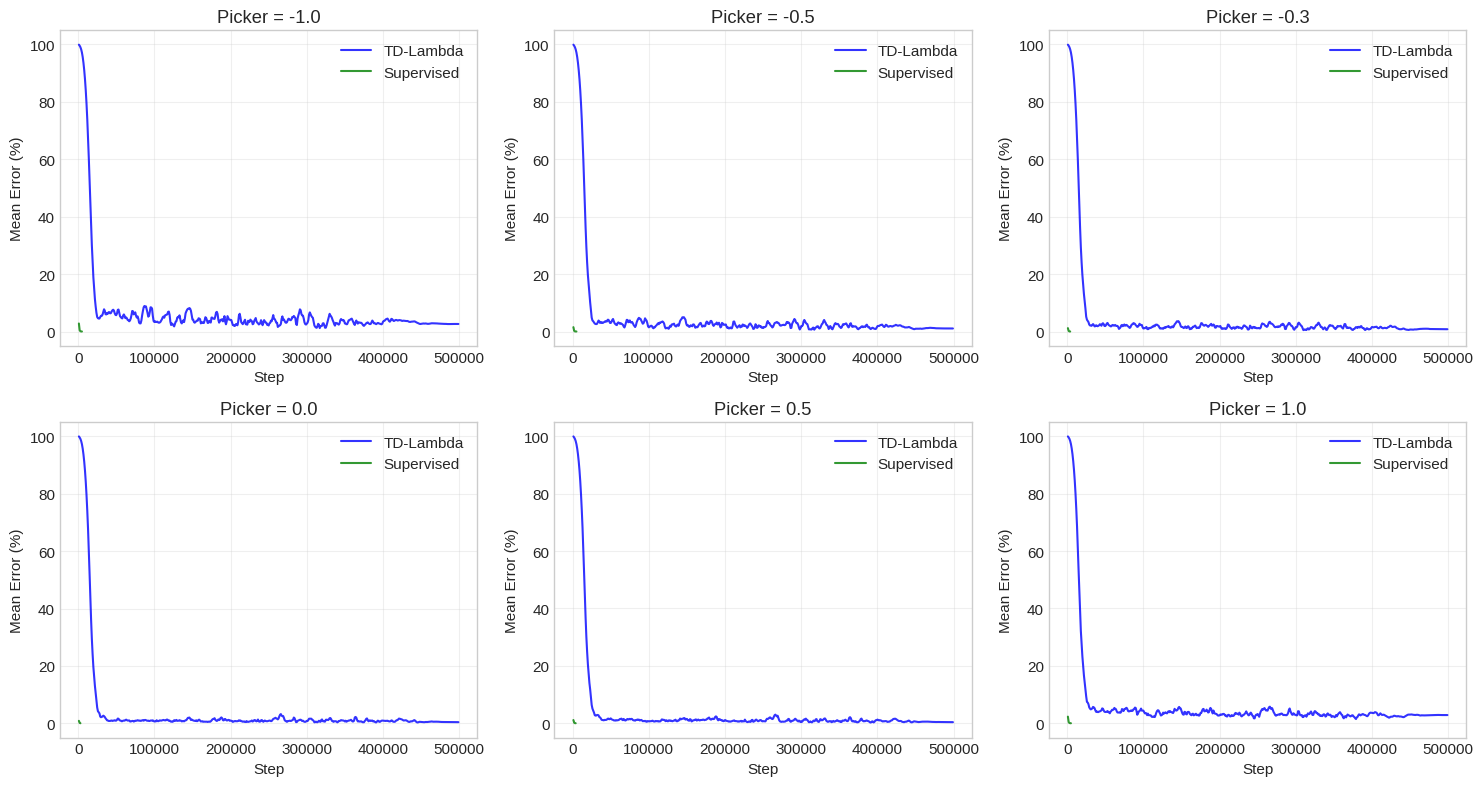

In [24]:
# Compare learning curves for specific picker penalties
selected_penalties = [-1.0, -0.5, -0.3, 0.0, 0.5, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, penalty in zip(axes, selected_penalties):
    # TD-Lambda curve
    td_curve = combined_df[(combined_df['method'] == 'td_lambda') & 
                           (np.isclose(combined_df['picker_penalty'], penalty))]
    if not td_curve.empty and 'avg_mean_error' in td_curve.columns:
        ax.plot(td_curve['Step'], td_curve['avg_mean_error'], '-', label='TD-Lambda', color='blue', alpha=0.8)
    
    # Supervised curve
    sup_curve = combined_df[(combined_df['method'] == 'supervised') & 
                            (np.isclose(combined_df['picker_penalty'], penalty))]
    if not sup_curve.empty and 'avg_mean_error' in sup_curve.columns:
        ax.plot(sup_curve['Step'], sup_curve['avg_mean_error'], '-', label='Supervised', color='green', alpha=0.8)
    
    ax.set_xlabel('Step')
    ax.set_ylabel('Mean Error (%)')
    ax.set_title(f'Picker = {penalty}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary Table

In [25]:
# Create summary table
summary_cols = ['picker_penalty', 'method', 'avg_mean_error', 'avg_bias', 'avg_agent_std', 'worst_max_error', 'Loss']
available_cols = [c for c in summary_cols if c in final_df.columns]

summary_table = final_df[available_cols].sort_values(['picker_penalty', 'method'])
summary_table = summary_table.round(3)

print("\n=== SUMMARY TABLE ===")
display(summary_table)


=== SUMMARY TABLE ===


,picker_penalty,method,avg_mean_error,avg_bias,avg_agent_std,worst_max_error,Loss
9,-2.00,supervised,0.015,0.002,0.002,0.96,0.000
29,-2.00,td_lambda,7.285,7.275,2.600,17.05,1.639
5,-1.00,supervised,0.022,0.000,0.010,0.52,0.000
16,-1.00,td_lambda,2.640,2.572,1.537,7.91,0.775
4,-0.70,supervised,0.022,0.000,0.002,0.38,0.000
2,-0.70,td_lambda,1.532,1.320,1.115,5.46,0.534
24,-0.50,supervised,0.020,0.000,0.010,0.30,0.000
22,-0.50,td_lambda,1.072,0.612,0.750,3.96,0.384
0,-0.40,supervised,0.020,0.000,0.010,0.31,0.000
3,-0.40,td_lambda,0.928,0.312,0.538,3.38,0.314


In [26]:
# Pivot for side-by-side comparison
if 'avg_mean_error' in final_df.columns:
    pivot_mean = final_df.pivot(index='picker_penalty', columns='method', values='avg_mean_error')
    pivot_mean['diff'] = pivot_mean.get('td_lambda', 0) - pivot_mean.get('supervised', 0)
    
    print("\n=== Mean Error: TD-Lambda vs Supervised ===")
    display(pivot_mean.round(3))

if 'avg_bias' in final_df.columns:
    pivot_bias = final_df.pivot(index='picker_penalty', columns='method', values='avg_bias')
    pivot_bias['diff'] = pivot_bias.get('td_lambda', 0) - pivot_bias.get('supervised', 0)
    
    print("\n=== Bias: TD-Lambda vs Supervised ===")
    display(pivot_bias.round(3))


=== Mean Error: TD-Lambda vs Supervised ===


method,supervised,td_lambda,diff
picker_penalty,,,
-2.00,0.015,7.285,7.270
-1.00,0.022,2.640,2.618
-0.70,0.022,1.532,1.510
-0.50,0.020,1.072,1.052
-0.40,0.020,0.928,0.908
-0.30,0.028,0.818,0.790
-0.20,0.025,0.698,0.672
-0.10,0.020,0.565,0.545
0.00,0.040,0.418,0.378



=== Bias: TD-Lambda vs Supervised ===


method,supervised,td_lambda,diff
picker_penalty,,,
-2.00,0.002,7.275,7.272
-1.00,0.000,2.572,2.572
-0.70,0.000,1.320,1.320
-0.50,0.000,0.612,0.612
-0.40,0.000,0.312,0.312
-0.30,0.000,0.080,0.080
-0.20,0.000,-0.053,-0.053
-0.10,0.000,-0.073,-0.073
0.00,-0.008,-0.018,-0.010


## 7. Key Insight: Does Supervised Fix the Problem?

In [27]:
# Analyze the threshold region
threshold_penalties = [-0.7, -0.5, -0.4, -0.3]

print("=== THRESHOLD REGION ANALYSIS ===")
print("\nDoes supervised learning eliminate the variance seen in TD-lambda?\n")

for penalty in threshold_penalties:
    td_row = final_df[(final_df['method'] == 'td_lambda') & (np.isclose(final_df['picker_penalty'], penalty))]
    sup_row = final_df[(final_df['method'] == 'supervised') & (np.isclose(final_df['picker_penalty'], penalty))]
    
    print(f"Picker Penalty = {penalty}:")
    
    if not td_row.empty and 'avg_mean_error' in td_row.columns:
        print(f"  TD-Lambda:  Mean={td_row['avg_mean_error'].values[0]:.2f}%, "
              f"Bias={td_row.get('avg_bias', pd.Series([0])).values[0]:.2f}%, "
              f"AgentStd={td_row.get('avg_agent_std', pd.Series([0])).values[0]:.2f}%")
    else:
        print(f"  TD-Lambda:  No data")
        
    if not sup_row.empty and 'avg_mean_error' in sup_row.columns:
        print(f"  Supervised: Mean={sup_row['avg_mean_error'].values[0]:.2f}%, "
              f"Bias={sup_row.get('avg_bias', pd.Series([0])).values[0]:.2f}%, "
              f"AgentStd={sup_row.get('avg_agent_std', pd.Series([0])).values[0]:.2f}%")
    else:
        print(f"  Supervised: No data")
    print()

=== THRESHOLD REGION ANALYSIS ===

Does supervised learning eliminate the variance seen in TD-lambda?

Picker Penalty = -0.7:
  TD-Lambda:  Mean=1.53%, Bias=1.32%, AgentStd=1.11%
  Supervised: Mean=0.02%, Bias=0.00%, AgentStd=0.00%

Picker Penalty = -0.5:
  TD-Lambda:  Mean=1.07%, Bias=0.61%, AgentStd=0.75%
  Supervised: Mean=0.02%, Bias=0.00%, AgentStd=0.01%

Picker Penalty = -0.4:
  TD-Lambda:  Mean=0.93%, Bias=0.31%, AgentStd=0.54%
  Supervised: Mean=0.02%, Bias=0.00%, AgentStd=0.01%

Picker Penalty = -0.3:
  TD-Lambda:  Mean=0.82%, Bias=0.08%, AgentStd=0.36%
  Supervised: Mean=0.03%, Bias=0.00%, AgentStd=0.01%



In [28]:
# Final conclusion
print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print("""
If supervised learning shows LOW and UNIFORM error across all picker 
penalties while TD-lambda shows HIGH and VARIABLE error for penalties
>= 0.5, then:

  → TD mechanics (bootstrapping, target networks) are the cause
  → Reward variance destabilizes TD learning specifically

If BOTH methods show the same pattern (increasing error/variance for
higher picker penalties), then:

  → Something fundamental about reward magnitude affects learning
  → Possibly gradient scaling or network capacity issues
""")

CONCLUSION

If supervised learning shows LOW and UNIFORM error across all picker 
penalties while TD-lambda shows HIGH and VARIABLE error for penalties
>= 0.5, then:

  → TD mechanics (bootstrapping, target networks) are the cause
  → Reward variance destabilizes TD learning specifically

If BOTH methods show the same pattern (increasing error/variance for
higher picker penalties), then:

  → Something fundamental about reward magnitude affects learning
  → Possibly gradient scaling or network capacity issues

